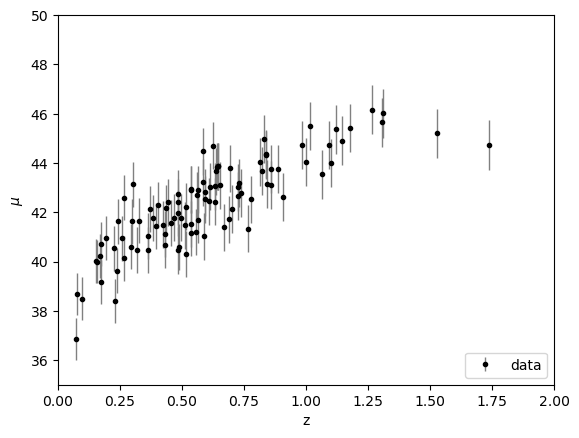

In [1]:
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [2]:
from astropy.cosmology import LambdaCDM
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

[39.56505555] [[4.64711848]]


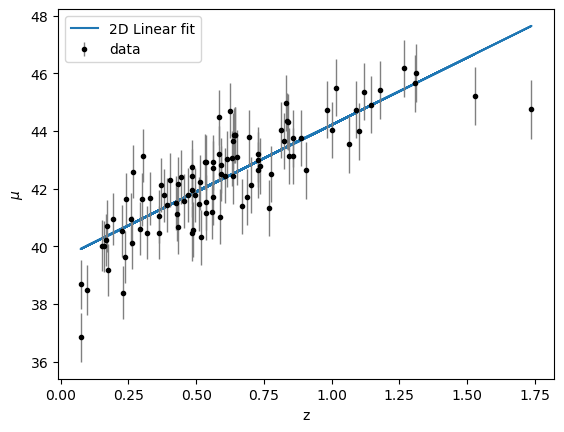

In [4]:
#Probar diferentes fittings
from sklearn.linear_model import LinearRegression
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(z_sample[:,np.newaxis], mu_sample[:,np.newaxis], sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)

y = theta0 + theta1[0] * z_sample

plt.plot(z_sample, y, label='2D Linear fit')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel('z')
plt.ylabel("$\mu$")
plt.legend();


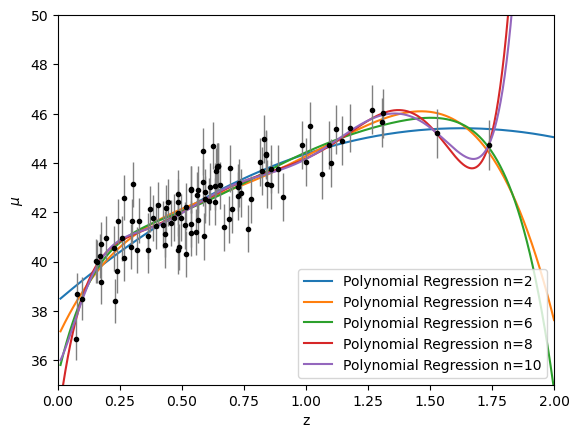

In [5]:
#explore polinomial regression
from astroML.linear_model import PolynomialRegression

z = np.linspace(0.01, 2, 1000)
n = [2, 4, 6, 8, 10 ] 

for i in n:
    model = PolynomialRegression(i)
    model.fit(z_sample[:,np.newaxis], mu_sample, dmu)
    mu_fit = model.predict(z[:,np.newaxis])
    plt.plot(z, mu_fit,label='Polynomial Regression n='+str(i))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
#print(regressor.coef_)

#6 seems to be the best

In [5]:
# alternative to cross validation

In [6]:
X = z_sample[:,np.newaxis]
y = mu_sample
dy = dmu

X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [7]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train,dy_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

Polynomial Regression n= 1 1.048511599667498 0.8238924629073977
Polynomial Regression n= 2 0.9385359114081159 0.8351995054159936
Polynomial Regression n= 3 0.9383899628086955 0.8354111725641477
Polynomial Regression n= 4 0.9024072712440722 0.8095703348999923
Polynomial Regression n= 5 0.8924469328124867 0.8143335829739232
Polynomial Regression n= 6 0.8905028171949843 0.8113859054713765
Polynomial Regression n= 7 0.8699559684825384 0.8163407910199041
Polynomial Regression n= 8 0.8695867558752084 0.8211204495388831
Polynomial Regression n= 9 0.8696086089176849 0.8218234527011997
Polynomial Regression n= 10 0.8666795023387633 0.8463777349822765
Polynomial Regression n= 11 0.8624581177548228 0.8513668729731029
Polynomial Regression n= 12 0.8558274202605187 0.8191597615560083
Polynomial Regression n= 13 0.8528955455388555 0.8247869037712562
Polynomial Regression n= 14 0.8407660006012594 0.8121591335797279
Best 4 0.8095703348999923


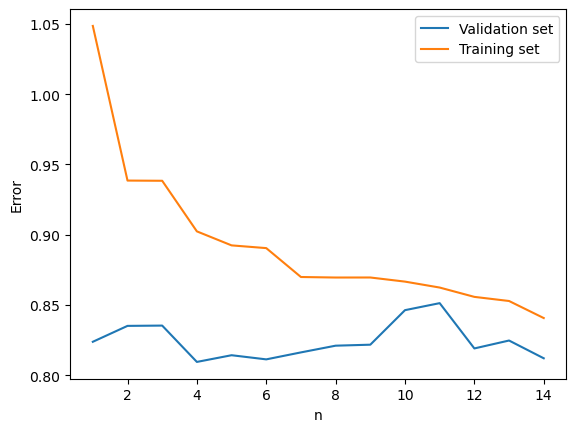

In [8]:
nrange = np.arange(1,15)

etrain, etest= [], []
for n in nrange:
    classifier = PolynomialRegression(n)
    error_train, error_validation = fitanderror(classifier)
    print("Polynomial Regression n=",n, error_train, error_validation)
    etrain.append(error_train)
    etest.append(error_validation)

plt.plot(nrange,etest, label='Validation set')
plt.plot(nrange,etrain, label='Training set')

plt.xlabel('n')
plt.ylabel('Error')
plt.legend()

print("Best", nrange[np.argmin(etest)], min(etest))

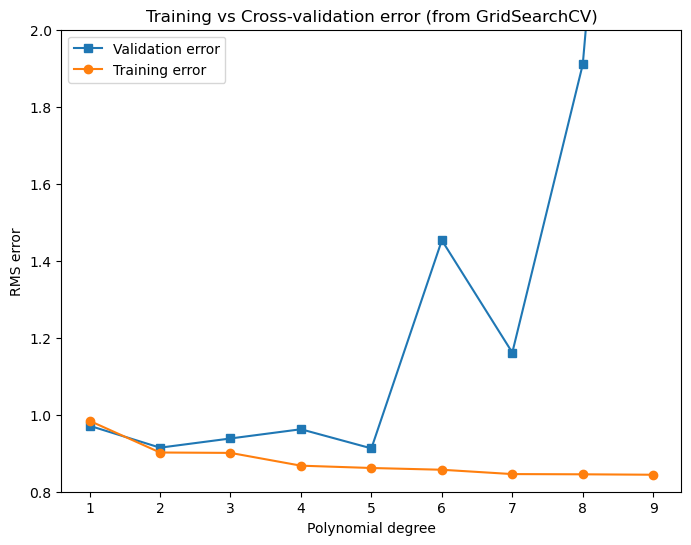

Best degree: 5


In [9]:
# Preparar el modelo y el grid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model = make_pipeline(PolynomialFeatures(), LinearRegression())
grid = GridSearchCV(model, {'polynomialfeatures__degree': np.arange(1, 10)}, cv=10, scoring='neg_root_mean_squared_error', return_train_score=True)
grid.fit(z_sample[:,np.newaxis], mu_sample)

train_error = -grid.cv_results_['mean_train_score']
val_error = -grid.cv_results_['mean_test_score']

plt.figure(figsize=(8,6))
plt.plot(np.arange(1, 10), val_error, label='Validation error', marker='s')
plt.plot(np.arange(1, 10), train_error, label='Training error', marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('RMS error')
plt.title('Training vs Cross-validation error (from GridSearchCV)')
plt.legend()
plt.ylim(0.8,2)
plt.show()
print("Best degree:", grid.best_params_['polynomialfeatures__degree'])

In [10]:
# i will say im underfitting from o to 5, ans then from 6 and so on Im overfiting bc im leaning more but the validation set show big errors.

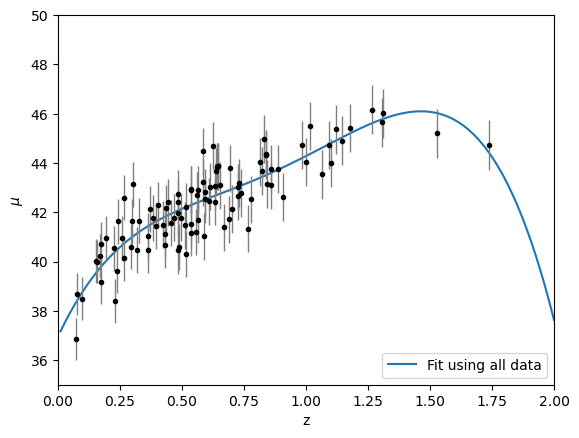

In [11]:
#lets ee how does the best fit looks like for polim.

classifier = PolynomialRegression(4)

classifier.fit(z_sample[:,np.newaxis], mu_sample,dmu) # in this case dy is irrelevant because errors are homoscedastic
mu_fit = classifier.predict(z[:,np.newaxis])

plt.plot(z, mu_fit, label='Fit using all data')


#classifier.fit(X_train, y_train,dy_train) # in this case dy is irrelevant because errors are homoscedastic
#mu_fit = classifier.predict(z[:,np.newaxis])

#plt.plot(z, mu_fit, label='Fit using only traning data')


#plt.errorbar(X_train, y_train, dy_train, fmt='.k', ecolor='gray', lw=1,label='Training data')
#plt.errorbar(X_validation, y_validation, dy_validation, fmt='.r', ecolor='red', lw=1, label='Validation data')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend(loc='lower right');

#may you add learning curves? yes

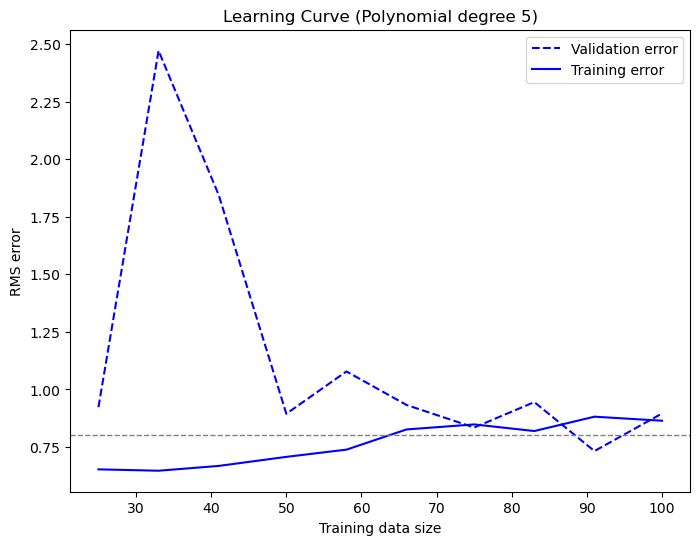

In [36]:
#learning curves

fixed_degree = 5
min_size = len(z_sample) // 4
max_size = len(z_sample)
steps = 10
sizes = np.linspace(min_size, max_size, steps, dtype=int)

train_errors = []
val_errors = []

for size in sizes:
    X_sub = z_sample[:size, np.newaxis]
    y_sub = mu_sample[:size]

    X_train, X_val, y_train, y_val = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

    model = make_pipeline(PolynomialFeatures(fixed_degree), LinearRegression())
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_rmse = np.sqrt(np.mean((y_train - y_train_pred) ** 2))
    val_rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))

    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

plt.figure(figsize=(8,6))
plt.plot(sizes, val_errors, label='Validation error', linestyle='--', color='b')
plt.plot(sizes, train_errors, label='Training error', color='b')
plt.axhline(y=0.8, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Training data size')
plt.ylabel('RMS error')
plt.title(f'Learning Curve (Polynomial degree {fixed_degree})')
plt.legend()
plt.show()